Combined DataFrame (first few rows):
             Timestamp  Steps  PAM Score
0  2025-06-04 14:00:00      7     1.5625
1  2025-06-04 14:01:00      9     0.5625
2  2025-06-04 14:04:00     42     5.3750
3  2025-06-04 14:05:00     49     4.0625
4  2025-06-04 14:06:00     66     4.8125
Total rows: 5743


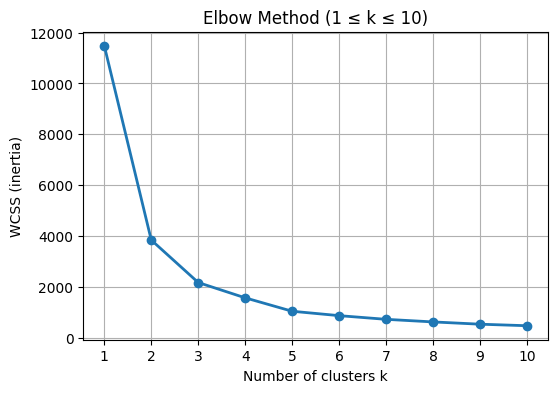

▶ Labeled data (with 'Timestamp' + 'tabel') saved to: ../clustered_output_k3.csv


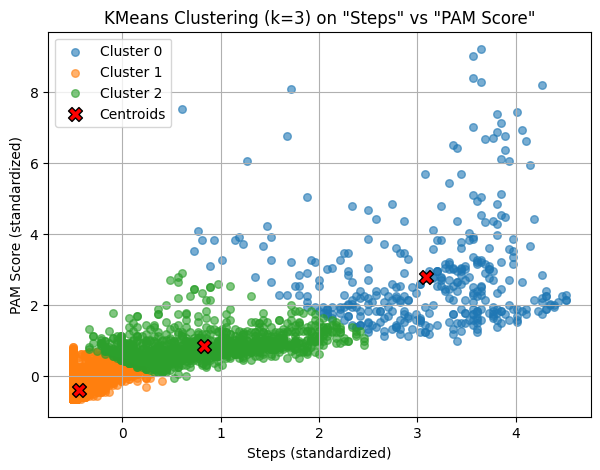

In [5]:
import pandas as pd
import glob
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# =============================================================================
# 1) READ & CONCATENATE ALL CSVs (INCLUDING “Timestamp”)
# =============================================================================

# Set the path to your folder containing the raw CSV files
folder_path = '../training_data/'

# Find all CSV files in that folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Read each CSV and concatenate into a single DataFrame
combined_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# Keep a copy of the full data (with Timestamp) for final export
original_df = combined_df.copy()

print("Combined DataFrame (first few rows):")
print(original_df.head())
print(f"Total rows: {len(original_df)}\n")

# =============================================================================
# 2) DROP “Timestamp” FOR CLUSTERING PURPOSES (BUT PRESERVE IT IN original_df)
# =============================================================================

# Remove the Timestamp column from combined_df before scaling/clustering
combined_df = combined_df.drop(columns=['Timestamp'])

# =============================================================================
# 3) SELECT NUMERIC COLUMNS & STANDARDIZE
# =============================================================================

numeric_df = combined_df.select_dtypes(include='number')
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# =============================================================================
# 4) OPTIONAL: ELBOW PLOT TO PICK n_clusters
# =============================================================================

wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state= 0, n_init=10)
    km.fit(scaled_data)
    wcss.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, wcss, 'o-', linewidth=2)
plt.title('Elbow Method (1 ≤ k ≤ 10)')
plt.xlabel('Number of clusters k')
plt.ylabel('WCSS (inertia)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# From the elbow plot, pick the “elbow”—for example, k = 3
# (You can change this later if you want a different number of clusters.)

# =============================================================================
# 5) DEFINE A FUNCTION TO RUN KMEANS, ATTACH LABELS, AND EXPORT CSV
# =============================================================================

def generate_labeled_csv(n_clusters: int):
    """
    Runs KMeans on scaled_data with the specified number of clusters.
    Attaches cluster labels as a new column "tabel" to original_df
    (which still has the "Timestamp" column), then exports to CSV.
    """
    # Fit KMeans and get cluster assignments
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_data)

    # Copy the full original DataFrame (including Timestamp)
    labeled_df = original_df.copy()
    labeled_df['tabel'] = cluster_labels

    # Export the labeled DataFrame to CSV
    output_filename = f'../clustered_output_k{n_clusters}.csv'
    labeled_df.to_csv(output_filename, index=False)
    print(f"▶ Labeled data (with 'Timestamp' + 'tabel') saved to: {output_filename}\n")

    # OPTIONAL: Plot “Steps” vs “Pam Score” in standardized space,
    # colored by cluster—just for verification.
    feat_x = numeric_df.columns[0]   # e.g. "Steps"
    feat_y = numeric_df.columns[1]   # e.g. "Pam Score"

    centroids_std = kmeans.cluster_centers_

    plt.figure(figsize=(7, 5))
    for cid in range(n_clusters):
        mask = (cluster_labels == cid)
        plt.scatter(
            scaled_data[mask, numeric_df.columns.get_loc(feat_x)],
            scaled_data[mask, numeric_df.columns.get_loc(feat_y)],
            s=30,
            alpha=0.6,
            label=f'Cluster {cid}'
        )

    plt.scatter(
        centroids_std[:, numeric_df.columns.get_loc(feat_x)],
        centroids_std[:, numeric_df.columns.get_loc(feat_y)],
        s=100,
        c='red',
        marker='X',
        edgecolor='k',
        label='Centroids'
    )

    plt.title(f'KMeans Clustering (k={n_clusters}) on "{feat_x}" vs "{feat_y}"')
    plt.xlabel(f'{feat_x} (standardized)')
    plt.ylabel(f'{feat_y} (standardized)')
    plt.legend()
    plt.grid(True)
    plt.show()

# =============================================================================
# 6) RUN THE FUNCTION TO PRODUCE THE LABELED CSV (e.g., WITH 3 CLUSTERS)
# =============================================================================

n_clusters = 3  # ← change to 2, 4, 5, etc. as desired
generate_labeled_csv(n_clusters=n_clusters)
